# Inverse design optimization of a compact grating coupler

**This notebook contains a long optimization. Running the entire notebook will cost about 10 FlexCredits and take a few hours.**

The ability to couple light in and out of photonic integrated circuits (PICs) is crucial for developing wafer-scale systems and tests. This need makes designing efficient and compact grating couplers an important task in the PIC development cycle. In this notebook, we will demonstrate how to use `tidy3d` to perform the inverse design of a compact 3D grating coupler. We will show how to improve design fabricability by enhancing permittivity binarization and controlling the device's minimum feature size.

<img src="img/adjoint_6.png" width=400 alt="Schematic of the grating coupler">

In addition, if you are interested in more conventional designs, we modeled an [uniform grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/GratingCoupler/) and a [Focusing apodized grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/FocusedApodGC/) in previous case studies. For more integrated photonic examples, please visit our [examples page](https://www.flexcompute.com/tidy3d/examples/). If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101](https://www.flexcompute.com/fdtd101/) tutorials. FDTD simulations can diverge due to various reasons. If you run into any simulation divergence issues, please follow the steps outlined in our [troubleshooting guide](https://www.flexcompute.com/tidy3d/examples/notebooks/DivergedFDTDSimulation/) to resolve it.

We start by importing our typical python packages, plus `autograd` and `tidy3d`.

In [2]:
# Standard python imports.
from typing import List

# Import autograd to be able to use automatic differentiation.
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import scipy as sp

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad

## Ian's Notes

Each iteration runs the simulation one time. Each iteration works as follows
1. Compute J(p) and dJ/dp
2. update p = p + (a)dJ/dp
3. run simulation again to compute J(p) and dJ/dp 

The objective function does the following in order
1. creates a simulation with the design region parameters at some p
2. runs the simulation and then calculates the FOM(figure of merit)
3. Subtracts the feature size penalty from the FOM and returns the value for J of that simulation

You pass this objective function into the value_and_grad function from the autograd function and that will calculate both your J(p) and the dJ/dp

## Grating Coupler Inverse Design Configuration

The grating coupler inverse design begins with a rectangular design region connected to a $Si$ waveguide. Throughout the optimization process, this initial structure evolves to convert a vertically incident Gaussian-like mode from an optical fiber into a guided mode and then funnel it into the $Si$ waveguide.

We are considering a full-etched grating structure, so a $SiO_{2}$ BOX layer is included. To reduce backreflection, we adjusted the fiber tilt angle to $10^{\circ}$ [[1](https://doi.org/10.1364/OE.23.022628), [2](https://doi.org/10.3390/mi11070666)].

In the following block of code, you can find the parameters that can be modified to configure the grating coupler structure, optimization, and simulation setup. Special care should be devoted to the `it_per_step` and `opt_steps` variables below.

In [3]:
# Geometric parameters.
w_thick = 0.22  # Waveguide thickness (um).
w_width = 0.5  # Waveguide width (um).
w_length = 1.0  # Waveguide length (um).
box_thick = 0.972  # SiO2 BOX thickness (um).
spot_size = 2.5  # Spot size of the input Gaussian field regarding a lensed fiber (um).
fiber_tilt = 10.0  # Fiber tilt angle (degrees).
src_offset = 0.05  # Distance between the source focus and device (um).
taper_length = 10.0 # Length of taper region in grating coupler

# Material.
nSi = 3.695  # Silicon refractive index.
nSiO2 = 1.44  # Silica refractive index.
nSi3N4 = 2.03 # Silicon nitride refractive index

# Design region parameters.
gc_width = 4.0  # Grating coupler width (um).
gc_length = 30.0  # Grating coupler length (um).
dr_grid_size = 0.020  # Grid size within the design region (um).

# Inverse design setup parameters.
#################################################################
# Total number of iterations = opt_steps x it_per_step.
it_per_step = 1  # Number of iterations per optimization step.
opt_steps = 25  # Number of optimization steps.
#################################################################
eta = 0.50  # Threshold value for the projection filter.
fom_name = "fom_field"  # Name of the monitor used to compute the objective function.

# Simulation wavelength.
wl = 0.729  # Central simulation wavelength (um).
bw = 0.02  # Simulation bandwidth (um).
n_wl = 10  # Number of wavelength points within the bandwidth.

# feature size
min_feature_size = 0.060
filter_radius = min_feature_size

# Buffer layer thickness
border_buffer = 0.16

# projection
beta_min = 1.0
beta_max = 30.0

In [4]:
total_iter = opt_steps * it_per_step
print(f"Total iterations = {total_iter}")

Total iterations = 25


## Inverse Design Optimization Set Up

We will calculate the values of some parameters used throughout the inverse design set up.

In [5]:
# Minimum and maximum values for the permittivities.
eps_max = nSi3N4**2
eps_min = 1.0
eps_si = nSi**2

# Material definitions.
mat_si = td.Medium(permittivity=eps_si)  # Si bottom layer material.
mat_sio2 = td.Medium(permittivity=nSiO2**2)  # BOX material.
mat_si3n4 = td.Medium(permittivity=eps_max) # Waveguide material

# Wavelengths and frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])
run_time = 5e-12

# Computational domain size.
pml_spacing = 0.6 * wl
size_x = pml_spacing + w_length + gc_length + taper_length + 2 * border_buffer
size_y = gc_width + 2 * pml_spacing + 2 * border_buffer
size_z = w_thick + box_thick + 2 * pml_spacing
center_z = size_z / 2 - pml_spacing - w_thick / 2
eff_inf = 1000

# Inverse design variables.
src_pos_z = w_thick / 2 + src_offset
#mon_pos_x = -size_x / 2 + w_length + taper_length - wl
mon_pos_x = -size_x/2 + wl
mon_w = int(3 * w_width / dr_grid_size) * dr_grid_size
mon_h = int(5 * w_thick / dr_grid_size) * dr_grid_size
nx = int((gc_length + 2 * border_buffer) / dr_grid_size)
ny = int((gc_width + 2 * border_buffer) / dr_grid_size / 2.0)
npar = int(nx * ny)
dr_size_x = nx * dr_grid_size
dr_size_y = 2 * ny * dr_grid_size
dr_center_x = -size_x / 2 + w_length + dr_size_x / 2 + taper_length
n_border = int(border_buffer / dr_grid_size)

First, we will introduce the simulation components that do not change during optimization, such as the $Si$ waveguide and $SiO_{2}$ BOX layer. Additionally, we will include a Gaussian source to drive the simulations, and a mode monitor to compute the objective function.

In [6]:
# Input/output waveguide.
waveguide = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -w_width / 2, -w_thick / 2),
        rmax=(-size_x / 2 + w_length, w_width / 2, w_thick / 2),
    ),
    medium=mat_si3n4,
)

# SiO2 BOX layer.
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -w_thick / 2 - box_thick),
        rmax=(eff_inf, eff_inf, -w_thick / 2),
    ),
    medium=mat_sio2,
)

# Si3N4 substrate.
si_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -eff_inf),
        rmax=(eff_inf, eff_inf, -w_thick / 2 - box_thick),
    ),
    medium=mat_si3n4,
)
taper_angle_rad = np.arctan((dr_size_y/2)/(taper_length))
source_size_x = dr_size_x-2*border_buffer
source_size_y = dr_size_y-2*border_buffer
# Gaussian source focused above the grating coupler.
gauss_source = td.AstigmaticGaussianBeam(
    center=(dr_center_x - dr_size_x/2 + source_size_x/4, 0, src_pos_z),
    size=(source_size_x, source_size_y, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    pol_angle=np.pi / 2, # TE Polarization
    angle_theta=fiber_tilt * np.pi / 180.0,
    direction="-",
    num_freqs=7,
    waist_sizes=(source_size_x/4, source_size_y/4),
    waist_distances=(0,0), #spot focuses 100um away
)

# Monitor where we will compute the objective function from.
mode_spec = td.ModeSpec(num_modes=1, target_neff=nSi3N4)
#monitor_size = np.tan(taper_angle_rad) * (taper_length-wl) * 2
monitor_size = w_width
fom_monitor = td.ModeMonitor(
    center=[mon_pos_x, 0, 0],
    size=[0, monitor_size, w_thick],
    freqs=[freq],
    mode_spec=mode_spec,
    name=fom_name,
)


x_start = -size_x/2 + w_length
x_end = x_start + taper_length 
y_flare_start = w_thick  # narrow end (near waveguide)
y_flare_end = np.tan(taper_angle_rad) * taper_length
vertices = [(x_start, -y_flare_start), (x_start, y_flare_start), (x_end, y_flare_end), (x_end, -y_flare_end)]
taper = td.Structure(
    geometry=td.PolySlab(
        vertices=vertices,
        axis=2,
        slab_bounds=(-w_thick/2, w_thick/2)
    ),
    medium=mat_si3n4,
)

Now, we will define a random vector of initial design parameters or load a previously designed structure.

> Note: if a previous optimization file is found, the optimizer will pick up where that left off instead.

In [7]:
init_par = np.random.uniform(0, 1, int(npar))
init_par = sp.ndimage.gaussian_filter(init_par, 1)
init_par = init_par.reshape((nx, ny))

### Fabrication Constraints

We will use the `tidy3d.plugins.autograd` plugin to introduce functions that improve device fabricability. A classical conic density filter, which is popular in topology optimization problems, is used to enforce a minimum feature size specified by the `filter_radius` variable. Next, a hyperbolic tangent projection function is applied to eliminate grayscale and obtain a binarized permittivity pattern. The `beta` parameter controls the sharpness of the transition in the projection function, and for better results, this parameter should be gradually increased throughout the optimization process. Finally, the design parameters are transformed into permittivity values. For a detailed review of these methods, refer to [[3](https://doi.org/10.1007/s00419-015-1106-4)].

We will also introduce a buffer layer around the design region to enhance fabricability at the interfaces. The permittivity is enforced to lower values within the buffer layer, except at the output waveguide connection where we want a smooth transition.

In [8]:
def get_eps(design_param: np.ndarray, beta: float = 1.00, binarize: bool = False) -> np.ndarray:
    """Returns the permittivities after applying a conic density filter on design parameters
    to enforce fabrication constraints, followed by a binarization projection function
    which reduces grayscale.
    Parameters:
        design_param: np.ndarray
            Vector of design parameters.
        beta: float = 1.0
            Sharpness parameter for the projection filter.
        binarize: bool = False
            Enforce binarization.
    Returns:
        eps: np.ndarray
            Permittivity vector.
    """

    # Calculates the permittivities from the transformed design parameters.
    eps = get_eps_values(design_param, beta=beta)
    if binarize:
        eps = anp.where(eps < (eps_min + eps_max) / 2, eps_min, eps_max)
    else:
        eps = anp.where(eps < eps_min, eps_min, eps)
        eps = anp.where(eps > eps_max, eps_max, eps)
    return eps

In [9]:
from tidy3d.plugins.autograd import make_filter_and_project, rescale

filter_project = make_filter_and_project(filter_radius, dr_grid_size, padding="constant")


def interface_buffer(params):
    """Introduce a buffer around design to enhance fabricability at the interfaces."""
    mask = anp.zeros_like(params)
    mask[0:n_border, :] = 0
    mask[nx - n_border :, :] = 0
    mask[:, ny - n_border :] = 0
    mask[0:n_border, 0 : int((y_flare_end) / dr_grid_size) + 1] = 1

    return params * (1 - mask) + mask


def pre_process(params, beta):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0,1)"""
    params1 = interface_buffer(params)
    params2 = filter_project(params1, beta=beta)
    params3 = filter_project(params2, beta=beta)
    return params3


def get_eps_values(params: np.ndarray, beta: float) -> np.ndarray:
    """Get the relative permittivity array given the parameters."""
    params = pre_process(params, beta=beta)
    eps_values = rescale(params, eps_min, eps_max)
    return eps_values

The permittivity values obtained from the design parameters are then used to build a [CustomMedium](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.CustomMedium.html). As we will consider symmetry about the x-axis in the simulations, only the upper-half part of the design region needs to be populated. A `Structure` built using the `CustomMedium` will be returned by the following function: 

In [10]:
def update_design(eps, unfold: bool = False) -> List[td.Structure]:
    """Reflects the structure about the x-axis."""
    nyii = ny
    y_min = 0
    dr_s_y = dr_size_y / 2
    dr_c_y = dr_s_y / 2
    eps_val = anp.array(eps).reshape((nx, ny, 1))
    if unfold:
        nyii = 2 * ny
        y_min = -dr_size_y / 2
        dr_s_y = dr_size_y
        dr_c_y = 0
        eps_val = anp.concatenate((anp.fliplr(anp.copy(eps_val)), eps_val), axis=1)

    # Definition of the coordinates x,y along the design region.
    coords_x = [(dr_center_x - (dr_size_x / 2)) + ix * dr_grid_size for ix in range(nx)]
    coords_y = [y_min + iy * dr_grid_size for iy in range(nyii)]
    coords = dict(x=coords_x, y=coords_y, z=[0])

    # Creation of a custom medium using the values of the design parameters.
    permittivity = td.SpatialDataArray(eps_val, coords=coords)
    eps_medium = td.CustomMedium(permittivity=permittivity)
    box = td.Box(center=(dr_center_x, dr_c_y, 0), size=(dr_size_x, dr_s_y, w_thick))
    design_structure = td.Structure(geometry=box, medium=eps_medium)
    return [design_structure]

Next, we will write a function to return the `td.Simulation` object. Note that we are using a `MeshOverrideStructure` to obtain a uniform mesh over the design region.

In [11]:
def make_adjoint_sim(
    design_param: np.ndarray,
    beta: float = 1.00,
    unfold: bool = False,
    binarize: bool = False,
) -> td.Simulation:
    # Builds the design region from the design parameters.
    eps = get_eps(design_param, beta, binarize) # returns the permittivites in a binarized form, so anything from 1.0 to si3n4's permittivites, it converts the parameter psace of design_param into binarized permittivites
    design_structure = update_design(eps, unfold=unfold) # create a structure out of those binarized permittivities

    # Creates a uniform mesh for the design region.
    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, w_thick)),
        dl=[dr_grid_size, dr_grid_size, dr_grid_size],
        enforce=True,
    )

    return td.Simulation(
        size=[size_x, size_y, size_z],
        center=[0, 0, -center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=wl_max,
            min_steps_per_wvl=15,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, -1, 0),
        structures=[waveguide, sio2_substrate, si_substrate, taper] + design_structure,
        sources=[gauss_source],
        monitors=[fom_monitor],
        run_time=run_time,
        subpixel=True,
    )

Let's visualize the simulation set up and verify if all the elements are in their correct places.

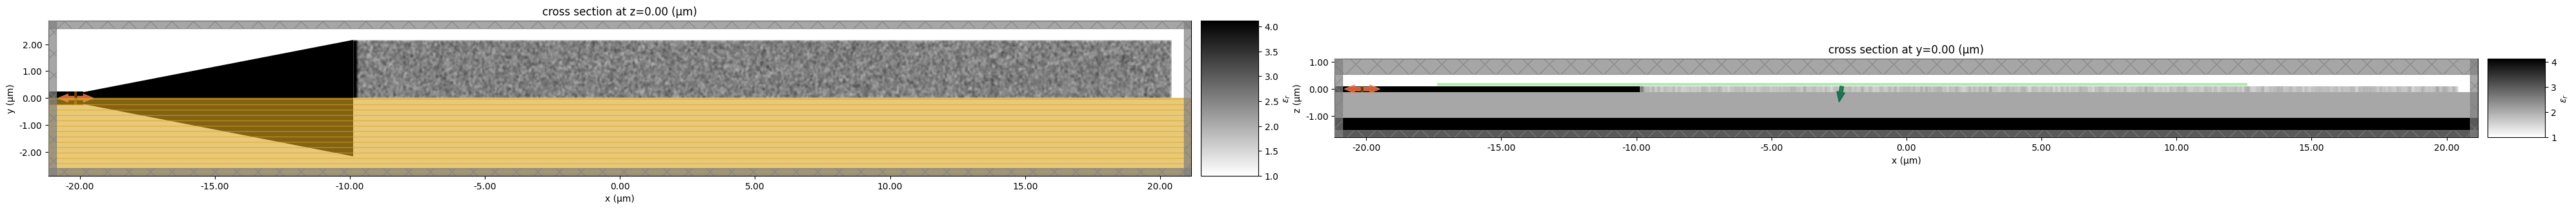

In [12]:
init_design = make_adjoint_sim(init_par, beta=beta_min)

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(40, 40))
init_design.plot_eps(z=0, ax=ax1)
init_design.plot_eps(y=0, ax=ax2)
plt.show()

init_design.plot_3d()

#job = web.Job(simulation=init_design)
#print(f"estimated cost of 40 iterations is {40 * web.estimate_cost(job.task_id)}")

In [13]:
from tidy3d.plugins.autograd import make_erosion_dilation_penalty

erode_dilate_penalty = make_erosion_dilation_penalty(filter_radius, dr_grid_size)


# Figure of Merit (FOM) calculation.
def fom(sim_data: td.SimulationData) -> float:
    """Return the power at the mode index of interest."""
    output_amps = sim_data[fom_name].amps
    amp = output_amps.sel(direction="-", f=freq, mode_index=0).values
    return anp.sum(anp.abs(amp) ** 2)


def penalty(params, beta) -> float:
    """Penalty function based on amount of change in parameters after erosion and dilation."""
    params_processed = pre_process(params, beta=beta)
    return erode_dilate_penalty(params_processed)

#latest_sim_data = None

# Objective function to be passed to the optimization algorithm.
def obj(design_param, beta: float = 1.0, step_num: int = None, verbose: bool = False) -> float:
    #global latest_sim_data
    sim = make_adjoint_sim(design_param, beta)
    task_name = "inv_des"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    #latest_sim_data = sim_data
    fom_val = fom(sim_data)
    feature_size_penalty = penalty(design_param, beta=beta)
    J = fom_val - feature_size_penalty 
    return J


# Function to calculate the objective function value and its
# gradient with respect to the design parameters.
obj_grad = value_and_grad(obj)

## Source Test

In [14]:
source_test_monitor = td.FieldMonitor(
    center=(dr_center_x, 0, w_thick),
    size=(size_x, size_y, 0),
    name="source_test_monitor",
    freqs=[freq]
)
source_test_sim = init_design.updated_copy(monitors=([source_test_monitor]))
job = web.Job(simulation=source_test_sim)
source_test_sim_data = job.run()

21:01:17 PDT Created task 'fdtd_2026-03-19_21-01-17' with resource_id           
             'fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=653885;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=309765;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\taskId]8;;\]8;id=653885;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\=]8;;\]8;id=147206;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\fdve]8;;\]8;id=653885;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\-8b4b4b78-8d7]8;;\
             ]8;id=653885;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\e-4f95-9f8e-0c137d30d755']8;;\.

             Task folder: ]8;id=267481;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

21:01:19 PDT Estimated FlexCredit cost: 1.121. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

21:01:50 PDT status = success

21:01:52 PDT View simulation result at                                          
             ]8;id=187236;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=953961;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\taskId]8;;\]8;id=187236;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\=]8;;\]8;id=563739;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\fdve]8;;\]8;id=187236;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\-8b4b4b78-8d7]8;;\
             ]8;id=187236;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8b4b4b78-8d7e-4f95-9f8e-0c137d30d755\e-4f95-9f8e-0c137d30d755']8;;\.

Output()

21:01:53 PDT Loading simulation from simulation_data.hdf5

<Axes: title={'center': 'cross section at z=0.22 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

<Figure size 600x500 with 0 Axes>

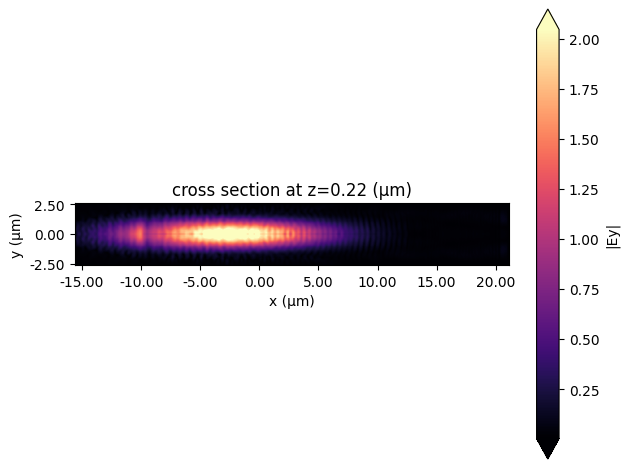

In [15]:
plt.figure(figsize=(6, 5))
source_test_sim_data.plot_field(field_monitor_name="source_test_monitor", field_name='Ey', val='abs')

## Optimization

We need to provide an objective function and its gradients with respect to the design parameters of the optimization algorithm.

Our figure-of-merit (FOM) is the coupling efficiency of the incident power into the fundamental transverse electric mode of the $Si$ waveguide. The optimization algorithm will call the objective function at each iteration step. Therefore, the objective function will create the adjoint simulation, run it, and return the FOM value.

Next we will define the optimizer using `optax`. We will save the optimization progress in a `pickle` file. If that file is found, it will pick up the optimization from the last state. Otherwise, we will create a blank history.

In [16]:
import pickle

import optax

# hyperparameters
learning_rate = 0.2
optimizer = optax.adam(learning_rate=learning_rate)

# where to store history
history_fname = "misc/grating_coupler_history_autograd_farfield.pkl"


def save_history(history_dict: dict) -> None:
    """Convenience function to save the history to file."""
    with open(history_fname, "wb") as file:
        pickle.dump(history_dict, file)


def load_history() -> dict:
    """Convenience method to load the history from file."""
    with open(history_fname, "rb") as file:
        history_dict = pickle.load(file)
    return history_dict

### Checking For a Previous Optimization

If `history_fname` is a valid file, the results of a previous optimization are loaded, then the optimization will continue from the last iteration step. If the optimization was completed, only the final structure will be simulated. The pickle file used in this notebook can be downloaded from our documentation [repo](https://github.com/flexcompute/tidy3d-notebooks/tree/develop/misc).

In [17]:
try:
    history_dict = load_history()
    opt_state = history_dict["opt_states"][-1]
    params = history_dict["params"][-1]
    num_iters_completed = len(history_dict["params"])
    print("Loaded optimization checkpoint from file.")
    print(f"Found {num_iters_completed} iterations previously completed out of {total_iter} total.")
    if num_iters_completed < total_iter:
        print("Will resume optimization.")
    else:
        print("Optimization completed, will return results.")

except FileNotFoundError:
    params = np.array(init_par)
    opt_state = optimizer.init(params)
    history_dict = dict(
        values=[],
        params=[],
        gradients=[],
        opt_states=[opt_state],
        data=[],
        beta=[],
    )

In [18]:
iter_done = len(history_dict["values"])
td.config.logging_level = "ERROR"
for i in range(iter_done, total_iter):
    print(f"iteration = ({i + 1} / {total_iter})")

    # compute gradient and current objective function value
    perc_done = i / (total_iter - 1)
    beta_i = beta_min * (1 - perc_done) + beta_max * perc_done
    #beta_i = beta_min
    value, gradient = obj_grad(params, beta=beta_i)

    #sim_data_i = latest_sim_data

    # outputs
    print(f"\tbeta = {beta_i}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient (-1 sign to maximize obj_fn)
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params[:] = optax.apply_updates(params, updates)

    # cap parameters between 0 and 1
    np.clip(params, 0.0, 1.0, out=params)

    # save history
    history_dict["values"].append(value)
    history_dict["params"].append(params)
    history_dict["beta"].append(beta_i)
    history_dict["gradients"].append(gradient)
    history_dict["opt_states"].append(opt_state)
    #history_dict["data"].append(sim_data_i) # uncomment to store data, can create large files
    save_history(history_dict)
    td.config.logging_level = "WARNING"

iteration = (1 / 25)
	beta = 1.0
	J = -9.9769e-01
	grad_norm = 8.5106e-05
iteration = (2 / 25)
	beta = 2.2083333333333335
	J = -9.3076e-01
	grad_norm = 6.8240e-03
iteration = (3 / 25)
	beta = 3.4166666666666665
	J = -6.3713e-01
	grad_norm = 9.0642e-03
iteration = (4 / 25)
	beta = 4.625
	J = -2.5386e-01
	grad_norm = 8.8825e-03
iteration = (5 / 25)
	beta = 5.833333333333333
	J = -8.7946e-02
	grad_norm = 5.2138e-03
iteration = (6 / 25)
	beta = 7.041666666666667
	J = -3.1563e-02
	grad_norm = 2.9591e-03
iteration = (7 / 25)
	beta = 8.25
	J = -7.7844e-03
	grad_norm = 2.5057e-03
iteration = (8 / 25)
	beta = 9.458333333333334
	J = 5.2566e-03
	grad_norm = 2.1529e-03
iteration = (9 / 25)
	beta = 10.666666666666666
	J = 1.2290e-02
	grad_norm = 1.9015e-03
iteration = (10 / 25)
	beta = 11.875
	J = 1.6171e-02
	grad_norm = 2.0783e-03
iteration = (11 / 25)
	beta = 13.083333333333334
	J = 1.9223e-02
	grad_norm = 1.4501e-03
iteration = (12 / 25)
	beta = 14.291666666666666
	J = 2.1274e-02
	grad_norm = 9.

22:32:38 PDT WARNING: No connection: Retrying for 180 seconds.                  

22:32:41 PDT ERROR: No internet connection: giving up on connection waiting.    

WebError: No internet connection: giving up on connection waiting.

### Optimization Results

After 150 iterations, a coupling efficiency value of 0.71 (-1.48 dB) was achieved at the central wavelength.

In [ ]:
obj_vals = np.array(history_dict["values"])
final_par = history_dict["params"][-1]
final_beta = history_dict["beta"][-1]

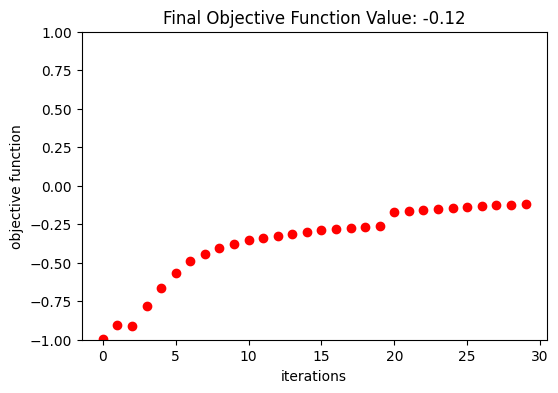

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(obj_vals, "ro")
ax.set_xlabel("iterations")
ax.set_ylabel("objective function")
ax.set_ylim(-1, 1)
ax.set_title(f"Final Objective Function Value: {obj_vals[-1]:.2f}")
plt.show()

The final grating coupler structure is well binarized, with mostly black (`eps_max`) and white (`eps_min`) regions.

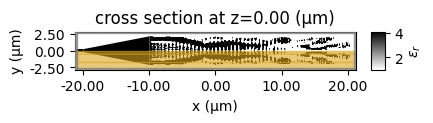

In [ ]:
fig, ax = plt.subplots(1, figsize=(4, 4))
sim_final = make_adjoint_sim(final_par, beta=final_beta, unfold=True)
sim_final.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax)
plt.show()

Once the inverse design is complete, we can visualize the field distributions and the wavelength dependent coupling efficiency.

In [ ]:
# Field monitors to visualize the final fields.
field_xy = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="field_xy",
)

field_xz = td.FieldMonitor(
    size=(td.inf, 0, td.inf),
    freqs=[freq],
    name="field_xz",
)

# Monitor to compute the grating coupler efficiency.
gc_efficiency = td.ModeMonitor(
    center=[mon_pos_x, 0, 0],
    size=[0, mon_w, mon_h],
    freqs=freqs,
    mode_spec=mode_spec,
    name="gc_efficiency",
)

sim_final = sim_final.copy(update=dict(monitors=(field_xy, field_xz, gc_efficiency)))
#sim_data_final = web.run(sim_final, task_name="inv_des_final")
job = web.Job(simulation=sim_final, task_name="inv_des_final")
estimated_cost = web.estimate_cost(job.task_id)
sim_data_final = job.run(path="data/sim.hdf5")

13:01:12 PDT Created task 'inv_des_final' with resource_id                      
             'fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=825648;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=247686;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\taskId]8;;\]8;id=825648;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\=]8;;\]8;id=977062;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\fdve]8;;\]8;id=825648;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\-2e9eafd1-99b]8;;\
             ]8;id=825648;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\f-4678-a7a4-c3c4ea7b4ffc']8;;\.

             Task folder: ]8;id=863422;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

13:01:13 PDT Estimated FlexCredit cost: 1.127. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

13:01:53 PDT status = success

13:01:55 PDT View simulation result at                                          
             ]8;id=210215;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=942338;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\taskId]8;;\]8;id=210215;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\=]8;;\]8;id=757929;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\fdve]8;;\]8;id=210215;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\-2e9eafd1-99b]8;;\
             ]8;id=210215;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2e9eafd1-99bf-4678-a7a4-c3c4ea7b4ffc\f-4678-a7a4-c3c4ea7b4ffc']8;;\.

Output()

13:01:56 PDT Loading simulation from data/sim.hdf5

In [ ]:
mode_amps = sim_data_final["gc_efficiency"]
coeffs_f = mode_amps.amps.sel(direction="-")
power_0 = np.abs(coeffs_f.sel(mode_index=0)) ** 2
power_0_db = 10 * np.log10(power_0)

sim_plot = sim_final.updated_copy(symmetry=(0, 0, 0), monitors=(field_xy, field_xz, gc_efficiency))
sim_data_plot = sim_data_final.updated_copy(simulation=sim_plot)

f, ax = plt.subplots(2, 2, figsize=(8, 6), tight_layout=True)
sim_plot.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax[0, 1])
ax[1, 0].plot(wl_range, power_0_db, "-k")
ax[1, 0].set_xlabel("Wavelength (um)")
ax[1, 0].set_ylabel("Power (db)")
ax[1, 0].set_ylim(-15, 0)
ax[1, 0].set_xlim(wl - bw / 2, wl + bw / 2)
ax[1, 0].set_title("Coupling Efficiency")
sim_data_plot.plot_field("field_xy", "Ey", "abs^2", z=0, ax=ax[1, 1])
ax[0, 0].plot(obj_vals, "ro")
ax[0, 0].set_xlabel("iterations")
ax[0, 0].set_ylabel("objective function")
ax[0, 0].set_ylim(-1, 1)
ax[0, 0].set_title(f"Final Objective Function Value: {obj_vals[-1]:.2f}")
plt.show()

NameError: name 'sim_data_final' is not defined

In [ ]:
new_source = td.ModeSource(
    center=gc_efficiency.center,
    size=gc_efficiency.size,
    source_time=td.GaussianPulse(freq0=freq, fwidth=freq/10),
    direction="+",  # Firing back into the waveguide toward the grating
    mode_spec=td.ModeSpec(num_modes=1),
    mode_index=0,
)

field_xy_elevated = td.FieldMonitor(
    center=(dr_center_x, 0, src_pos_z),
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="field_xy_elevated",
)

sim_farfield = sim_final.copy(
    update=dict(
        sources=[new_source],
        monitors=[field_xy_elevated]
    )
)

job = web.Job(simulation=sim_farfield, task_name="inv_des_final")
estimated_cost = web.estimate_cost(job.task_id)
sim_data_farfield = job.run(path="data/farfield_sim.hdf5")

r_proj = 100.0
x_proj = np.linspace(dr_center_x - 30, dr_center_x + 30, 100)
y_proj = np.linspace(-10, 10, 100)

monitor_far = td.FieldProjectionCartesianMonitor(
    center=(dr_center_x, 0, src_pos_z),
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="far_field",
    proj_axis=2,
    x=list(x_proj),
    y=list(y_proj),
    proj_distance=r_proj,
    far_field_approx=True,
)

def get_proj_fields(sim_data, monitor_near, monitor_far, pts_per_wavelength=10):
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data,
        near_monitors=[monitor_near],
        normal_dirs=["+"],
        pts_per_wavelength=pts_per_wavelength,
    )
    return projector.project_fields(monitor_far)

projected_field_data = get_proj_fields(sim_data_farfield, field_xy_elevated, monitor_far)

In [ ]:
def make_field_plot(x, y, intensity):
    fig, ax = plt.subplots(1, 1, tight_layout=True, figsize=(8, 4))
    im = ax.pcolormesh(x, y, np.real(intensity).T, cmap="hot", shading="auto")
    fig.colorbar(im, ax=ax)
    ax.set_title("Far-field intensity at 100 µm")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    plt.show()

fields = projected_field_data.fields_cartesian
Ex_proj = fields.Ex.isel(f=0)
Ey_proj = fields.Ey.isel(f=0)
Ez_proj = fields.Ez.isel(f=0)
intensity = np.abs(Ex_proj)**2 + np.abs(Ey_proj)**2 + np.abs(Ez_proj)**2
make_field_plot(x_proj, y_proj, intensity)

In [ ]:
loss_db = max(power_0_db)
print(f"optimized loss of {loss_db:.2f} dB")

optimized loss of -5.39 dB


## Export to GDS
The `Simulation` object has the [.to_gds_file](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html#tidy3d.Simulation.to_gds_file) convenience function to export the final design to a `GDS` file. In addition to a file name, it is necessary to set a cross-sectional plane (`z = 0` in this case) on which to evaluate the geometry, a `frequency` to evaluate the permittivity, and a `permittivity_threshold` to define the shape boundaries in custom mediums. See the [GDS export](https://www.flexcompute.com/tidy3d/examples/notebooks/GDSExport/) notebook for a detailed example on using `.to_gds_file` and other GDS related functions.

In [ ]:
sim_final.to_gds_file(
    fname="./misc/inverse_designed_gc.gds",
    z=0,
    permittivity_threshold=(eps_max + eps_min) / 2,
    frequency=freq,
)